# 04 · Machine-learning forecasting with skforecast

**Idea: reduce forecasting to supervised regression.** Build a design matrix from lags (and other features) and fit any scikit-learn regressor. Here that is LightGBM, a gradient-boosted tree ensemble.

$$y_t = f\big(y_{t-1}, \dots, y_{t-p},\ \mathbf{w}_t,\ \mathbf{x}_t\big) + \varepsilon_t$$

- $y_{t-1..t-p}$: **lags**.
- $\mathbf w_t$: **window features**, e.g. a rolling mean over the last 24 h.
- $\mathbf x_t$: **exogenous** variables known at time $t$, here the calendar sin/cos.

[skforecast](https://skforecast.org) builds these matrices, handles the multi-step strategy, backtesting and probabilistic intervals.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
from tsforecasting.data.data_loader import load_airline, load_jena, temporal_split
from tsforecasting.features.build_features import TARGET

try:
    df = load_jena()
except FileNotFoundError:  # first run: download + clean + features
    from tsforecasting.data import make_dataset
    from tsforecasting.features import build_features
    make_dataset.main(); build_features.main()
    df = load_jena()
y = df[TARGET]
airline = load_airline()
df.shape, airline.shape

((70128, 19), (144,))

In [3]:
import lightgbm as lgb
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterRecursive

CAL = ["Day sin", "Day cos", "Year sin", "Year cos"]
train_df, val_df, test_df = temporal_split(df)
data = df.iloc[-24 * 365 * 3 :]  # last 3 years keep the notebook fast
end_train = val_df.index[-1]

## 1. What does the regressor actually see?

`create_train_X_y` exposes the lag matrix. Each row is one training example and the target is $y_t$.

In [4]:
f = ForecasterRecursive(lgb.LGBMRegressor(verbose=-1), lags=[1, 2, 3, 24],
                        window_features=RollingFeatures(stats=["mean"], window_sizes=24))
X_demo, y_demo = f.create_train_X_y(y=data[TARGET].iloc[:200], exog=data[CAL].iloc[:200])
pd.concat([X_demo, y_demo.rename("target y_t")], axis=1).head()

,lag_1,lag_2,lag_3,lag_24,roll_mean_24,Day sin,Day cos,Year sin,Year cos,target y_t
time,,,,,,,,,,
2014-01-03 01:00:00,5.79,5.52,5.55,1.96,5.059583,0.258819,0.965926,0.040788,0.999168,4.99
2014-01-03 02:00:00,4.99,5.79,5.52,2.52,5.185833,0.500000,0.866025,0.041504,0.999138,4.24
2014-01-03 03:00:00,4.24,4.99,5.79,3.52,5.257500,0.707107,0.707107,0.042220,0.999108,4.35
2014-01-03 04:00:00,4.35,4.24,4.99,3.11,5.292083,0.866025,0.500000,0.042936,0.999078,5.22
2014-01-03 05:00:00,5.22,4.35,4.24,3.55,5.380000,0.965926,0.258819,0.043653,0.999047,5.40


## 2. Multi-step strategies

To forecast $H$ steps with a one-step regressor there are two classical strategies:

**Recursive (iterated):** one model $f$; feed predictions back as lags,
$$\hat y_{T+1}=f(y_T,\dots),\quad \hat y_{T+2}=f(\hat y_{T+1}, y_T,\dots),\ \dots$$
It is cheap (one model) but errors **compound** along the horizon.

**Direct:** one model per step $h$, $\hat y_{T+h}=f_h(y_T,\dots,y_{T-p+1})$. There is no error feedback, but it needs $H$ models and each ignores the dependence between steps.

In [5]:
from skforecast.direct import ForecasterDirect

y_tr = data[TARGET].loc[:end_train]
X_tr = data[CAL].loc[:end_train]
rec = ForecasterRecursive(lgb.LGBMRegressor(n_estimators=300, verbose=-1), lags=48,
                          window_features=RollingFeatures(stats=["mean", "std"], window_sizes=24))
rec.fit(y=y_tr, exog=X_tr)
direct = ForecasterDirect(lgb.LGBMRegressor(n_estimators=300, verbose=-1), steps=24, lags=48)
direct.fit(y=y_tr, exog=X_tr)
rec

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48] 
Window features: ['roll_mean_24', 'roll_std_24'] 
Calendar features: None 
Window size: 48 
Series name: T (degC) 
Exogenous included: True 
Exogenous names: Day sin, Day cos, Year sin, Year cos 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2014-01-02 01:00:00'), Timestamp('2016-03-14 19:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 300, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-10-03 15:10:41 
Last fit date: 2026-10-03 15:10:42 
Skforecast version: 0.25.0 
Python version: 3.11.15 
Forecaster id: None

## 3. Backtesting with `TimeSeriesFold`

skforecast's backtester mirrors our `evaluation.backtest`. Here the models are trained once (`refit=False`) and then predict from consecutive origins over the test period, each time with the true last window.

In [6]:
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster

cv = TimeSeriesFold(steps=24, initial_train_size=len(data.loc[:end_train]), refit=False, verbose=False)
metrics, preds = {}, {}
for name, fc in {"recursive": rec, "direct": direct}.items():
    m, p = backtesting_forecaster(fc, y=data[TARGET], exog=data[CAL], cv=cv,
                                  metric="mean_absolute_error", show_progress=False)
    metrics[name], preds[name] = m.iloc[0, 0], p
pd.Series(metrics, name="MAE on test [°C]")

recursive    1.893341
direct       2.030676
Name: MAE on test [°C], dtype: float64

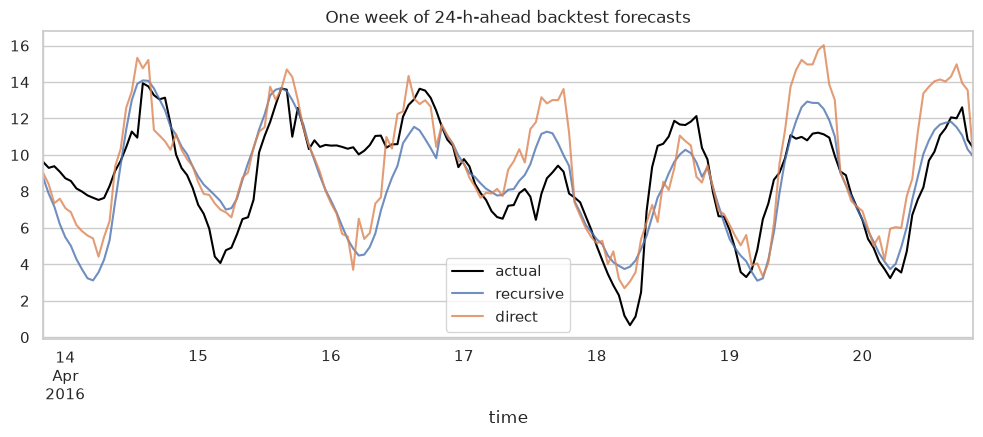

In [7]:
week = slice(test_df.index[24 * 30], test_df.index[24 * 37])
ax = data[TARGET].loc[week].plot(color="black", lw=1.5, label="actual")
for name, p in preds.items():
    p["pred"].loc[week].plot(ax=ax, label=name, alpha=0.8)
ax.set_title("One week of 24-h-ahead backtest forecasts"); ax.legend();

## 4. What did the trees learn?

Gain-based importance shows which lags and features LightGBM split on the most. Expect lag 1 (persistence), lag 24 (yesterday at the same hour) and the time-of-day encodings to dominate.

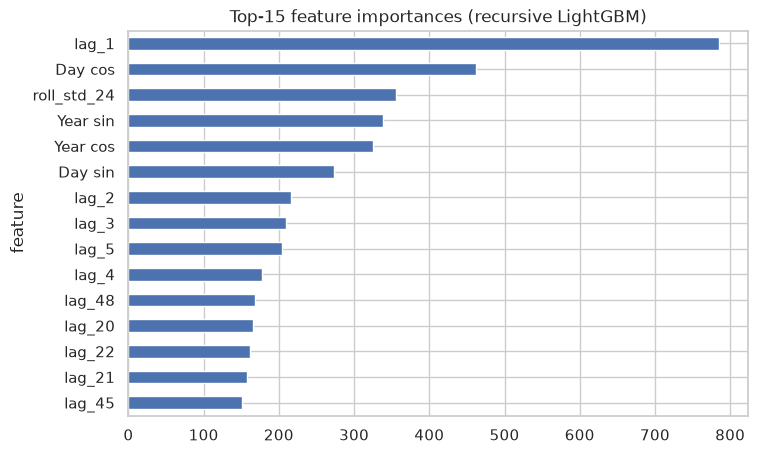

In [8]:
imp = rec.get_feature_importances().set_index("feature").importance.sort_values()
imp.tail(15).plot.barh(figsize=(8, 5), title="Top-15 feature importances (recursive LightGBM)");

## 5. Probabilistic forecasts

Tree ensembles output a point forecast. skforecast adds uncertainty from the model's **residuals**:

- **Bootstrapping**: simulate $B$ future paths by adding resampled residuals $\varepsilon^{*}$ at each recursive step, then take empirical quantiles. This propagates error through the recursion.
- **Conformal prediction** (split conformal): with calibration residuals $r_i = |y_i-\hat y_i|$, the interval $\hat y \pm \hat q_{1-\alpha}(r)$ has marginal coverage $\ge 1-\alpha$ under exchangeability.

Residuals should be **out-of-sample**. In-sample residuals of a boosted model are too small and give overconfident intervals. We store validation residuals with `set_out_sample_residuals`.

In [9]:
from tsforecasting.evaluation import interval_coverage

# out-of-sample residuals from the validation year
val_y = data[TARGET].loc[val_df.index[0] : end_train]
cv_val = TimeSeriesFold(steps=24, initial_train_size=len(data.loc[: val_df.index[0]]) - 1, refit=False, verbose=False)
_, p_val = backtesting_forecaster(rec, y=data[TARGET].loc[:end_train], exog=data[CAL].loc[:end_train],
                                  cv=cv_val, metric="mean_absolute_error", show_progress=False)
rec.set_out_sample_residuals(y_true=val_y.loc[p_val.index], y_pred=p_val["pred"])

cover = {}
for method in ["bootstrapping", "conformal"]:
    _, p = backtesting_forecaster(rec, y=data[TARGET], exog=data[CAL], cv=cv, metric="mean_absolute_error",
                                  interval=[0.1, 0.9], interval_method=method, use_in_sample_residuals=False,
                                  n_boot=100, show_progress=False)
    cover[method] = interval_coverage(data[TARGET].loc[p.index], p["lower_bound"], p["upper_bound"])
    preds[method] = p
pd.Series(cover, name="coverage of nominal 80% interval")

bootstrapping    0.970198
conformal        0.890204
Name: coverage of nominal 80% interval, dtype: float64

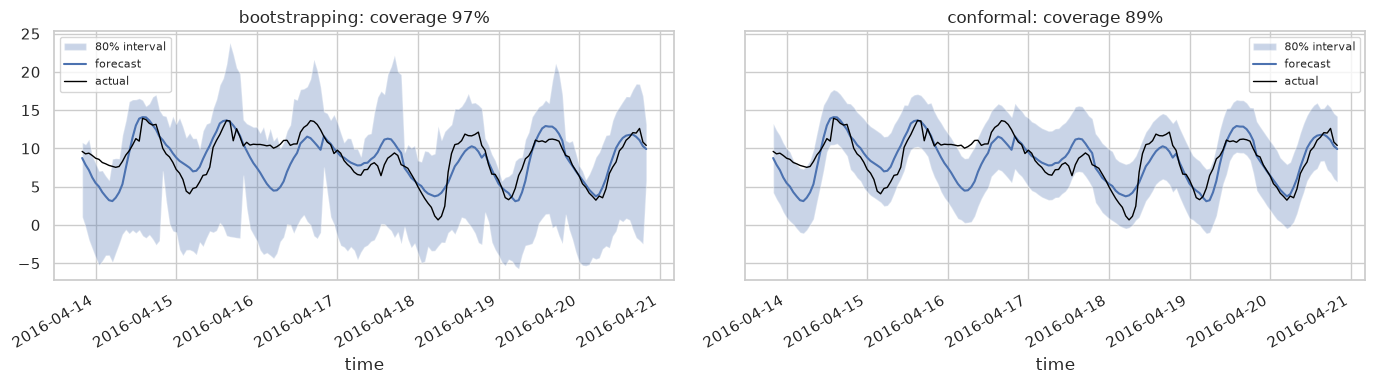

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, method in zip(axes, ["bootstrapping", "conformal"]):
    p = preds[method].loc[week]
    ax.fill_between(p.index, p["lower_bound"], p["upper_bound"], alpha=0.3, label="80% interval")
    ax.plot(p.index, p["pred"], label="forecast")
    data[TARGET].loc[week].plot(ax=ax, color="black", lw=1, label="actual")
    ax.set_title(f"{method}: coverage {cover[method]:.0%}"); ax.legend(fontsize=8)
fig.tight_layout()

## Takeaways
- Reduction to regression makes the whole scikit-learn/LightGBM toolbox available. It is the workhorse of practical forecasting competitions (M5).
- Multiple seasonalities are easy: add lag 24, calendar features and rolling statistics.
- The recursive and direct strategies trade error compounding against model count.
- Calibrate intervals with **out-of-sample** residuals and verify coverage empirically.